## Step 1: Environment Setup
This notebook starts by mounting Google Drive so the quiz datasets can be read directly from your Colab storage path.
This ensures all subsequent analysis uses the same source files consistently.

In [99]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [101]:
quize1 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/dataset/marks/quiz1/quiz1_marks.csv')
quize2 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/dataset/marks/quiz2/quiz2_marks.csv')
quize3 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/dataset/marks/quiz3/quiz3_marks.csv')


## Step 2: Data Preprocessing for Hypothesis Testing
Before testing the hypothesis, the quiz data is cleaned and standardized:
- Extra spaces in `Grade/10.00` are removed.
- Grades are converted to numeric values using `errors='coerce'` to handle invalid entries.
- Each quiz column is renamed (`quiz1`, `quiz2`, `quiz3`) for consistent analysis.
- The three quiz datasets are merged on `Student Code`.
- Rows with missing quiz grades are dropped to keep only complete student records.
- Scores are grouped by student to prepare a comparable dataset for correlation analysis.

   Student Code  quiz1  quiz2  quiz3
0             1    8.0    6.0    6.0
1             2    7.0    6.0    7.0
2             3    7.0    5.0    8.0
3             4    5.0    6.0    6.0
4             5    8.0    7.0    8.0
          quiz1     quiz2     quiz3
quiz1  1.000000  0.282371  0.304551
quiz2  0.282371  1.000000  0.207337
quiz3  0.304551  0.207337  1.000000


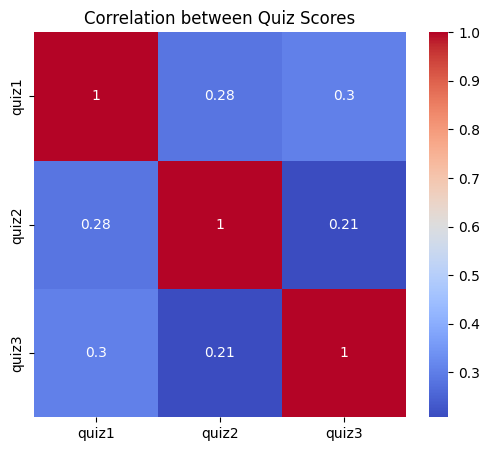

In [102]:
# Remove spaces, then convert to numeric
quize1['Grade/10.00'] = pd.to_numeric(quize1['Grade/10.00'].str.strip(), errors='coerce')
quize2['Grade/10.00'] = pd.to_numeric(quize2['Grade/10.00'].str.strip(), errors='coerce')
quize3['Grade/10.00'] = pd.to_numeric(quize3['Grade/10.00'].str.strip(), errors='coerce')

quiz1_marks = quize1[['Student Code', 'Grade/10.00']].rename(columns={'Grade/10.00': 'quiz1'})
quiz2_marks = quize2[['Student Code', 'Grade/10.00']].rename(columns={'Grade/10.00': 'quiz2'})
quiz3_marks = quize3[['Student Code', 'Grade/10.00']].rename(columns={'Grade/10.00': 'quiz3'})


# Merge quizzes
df_all = quiz1_marks.merge(quiz2_marks, on='Student Code', how='outer') \
                    .merge(quiz3_marks, on='Student Code', how='outer')

# Drop rows with any missing grades
df_all = df_all.dropna()

# Group by student and calculate mean per quiz
df_student = df_all.groupby('Student Code').mean().reset_index()

print(df_student.head())

# Correlation matrix
corr_matrix = df_student[['quiz1', 'quiz2', 'quiz3']].corr()
print(corr_matrix)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation between Quiz Scores')
plt.show()

## Step 3: Hypothesis Evaluation Approach
To evaluate whether students perform consistently across quizzes, you calculated a correlation matrix across `quiz1`, `quiz2`, and `quiz3`, then visualized it with a heatmap.
Interpretation rule used:
- Higher positive correlations (closer to 1) would support consistency.
- Low correlations indicate that strong consistency is not present.
Based on the observed low-to-moderate correlations, the hypothesis is rejected.

### Hypothesis Evaluation

**Hypothesis**: Students tend to exhibit consistent performance across all quizzes.

**Analysis**: A correlation heatmap was generated to visualize the relationships between student scores on `quiz1`, `quiz2`, and `quiz3`. The correlation coefficients are as follows:
- Quiz 1 and Quiz 2: 0.282371
- Quiz 1 and Quiz 3: 0.304551
- Quiz 2 and Quiz 3: 0.207337

**Verdict**: Hypothesis rejected.

**Reasoning**: The correlation coefficients are relatively low (ranging from approximately 0.21 to 0.30). This indicates a weak positive linear relationship between the quiz scores. If students exhibited consistent performance, we would expect to see much higher correlation coefficients (closer to 1), suggesting that a student's score on one quiz is strongly predictive of their score on another. The low correlations suggest that performance is not highly consistent across the three quizzes.